# Enbridge (ENB) Technical Analysis Notebook

This notebook covers:
1. Stock price analysis for the last one year
2. Volatility and return analysis
3. Monte Carlo simulation (100 simulations, 30 trading days ahead)
4. FB Prophet forecast
5. Comparison of Monte Carlo and Prophet results


## Install and import libraries

If `prophet` is not installed in your environment, uncomment the pip line and run it once.

In [1]:
# Uncomment this line if Prophet is not installed
# !pip install prophet

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

Importing plotly failed. Interactive plots will not work.


## Load and inspect the dataset

In [ ]:
file_path = 'Stock_and_Market_Data.xlsx'
raw_df = pd.read_excel(file_path, sheet_name=0)

print('Original columns:', list(raw_df.columns))
print('Shape:', raw_df.shape)
raw_df.head()

Original columns: ['Date', 'ENB', 'RM', 'Unnamed: 3', 'S&P 500', 'RM.1', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12']
Shape: (553, 13)


,Date,ENB,RM,Unnamed: 3,S&P 500,RM.1,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,2024-01-02,31.944403,NaN,NaN,4742.830078,NaN,NaN,NaN,NaN,2. CAPM and Cost of Equity,NaN,NaN,NaN
1,2024-01-03,32.094009,1.004683,NaN,4704.810059,0.991984,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01-04,32.120407,1.000823,NaN,4688.680176,0.996572,NaN,NaN,NaN,A. Define CAPM,NaN,NaN,NaN
3,2024-01-05,32.296413,1.005480,NaN,4697.240234,1.001826,NaN,NaN,NaN,B. Beta Calculation,NaN,NaN,NaN
4,2024-01-08,32.745213,1.013896,NaN,4763.540039,1.014115,NaN,NaN,NaN,C. Expected Return (CAPM Formula),NaN,NaN,NaN


## Clean the data

In [ ]:
# Keep only the useful columns
# The uploaded file contains extra empty columns named 'Unnamed: 2' and 'Unnamed: 3'
df = raw_df[['Date', 'ENB', 'S&P 500']].copy()

# Rename columns for easier use
df.columns = ['Date', 'ENB_Close', 'SP500_Close']

# Convert Date to datetime and sort
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Create daily returns
df['ENB_Return'] = df['ENB_Close'].pct_change()
df['SP500_Return'] = df['SP500_Close'].pct_change()

df.head()

,Date,ENB_Close,SP500_Close,ENB_Return,SP500_Return
0,2024-01-02,31.944403,4742.830078,NaN,NaN
1,2024-01-03,32.094009,4704.810059,0.004683,-0.008016
2,2024-01-04,32.120407,4688.680176,0.000823,-0.003428
3,2024-01-05,32.296413,4697.240234,0.005480,0.001826
4,2024-01-08,32.745213,4763.540039,0.013896,0.014115


# 1. Stock Price Analysis 
### Plot last one-year stock price 
### Provide graphical representation 
### Analyze volatility and trends 


In [ ]:
last_date = df['Date'].max()
one_year_ago = last_date - pd.DateOffset(years=1)
last_year_df = df[df['Date'] >= one_year_ago].copy()

print('Date range used for last one-year chart:')
print(last_year_df['Date'].min(), 'to', last_year_df['Date'].max())
print('Rows:', len(last_year_df))

Date range used for last one-year chart:
2025-03-17 00:00:00 to 2026-03-17 00:00:00
Rows: 252


## Last one-year stock price analysis

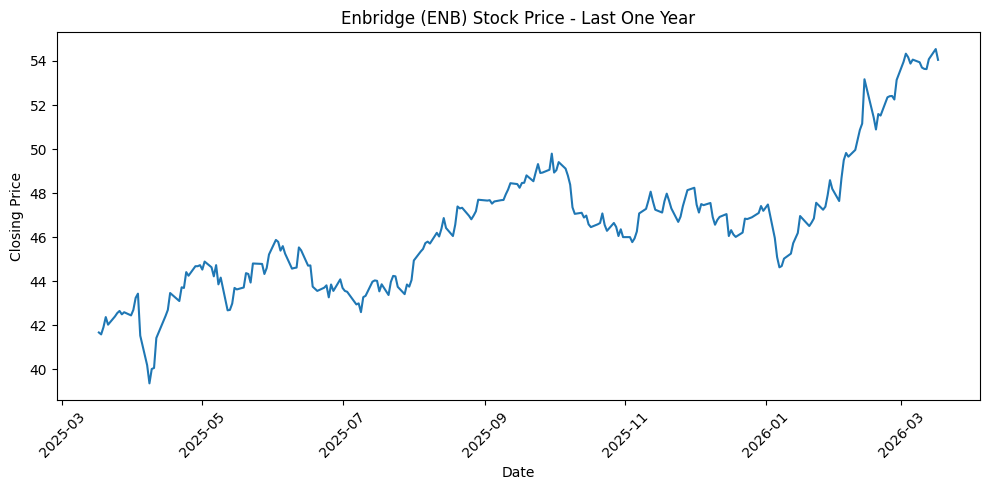

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(last_year_df['Date'], last_year_df['ENB_Close'])
plt.title('Enbridge (ENB) Stock Price - Last One Year')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Volatility and return analysis

In [ ]:
# Calculate volatility measures
daily_volatility = df['ENB_Return'].std()
annualized_volatility = daily_volatility * np.sqrt(252)
average_daily_return = df['ENB_Return'].mean()

print(f'Average Daily Return: {average_daily_return:.6f}')
print(f'Daily Volatility: {daily_volatility:.6f}')
print(f'Annualized Volatility: {annualized_volatility:.6f}')

Average Daily Return: 0.001005
Daily Volatility: 0.010184
Annualized Volatility: 0.161672


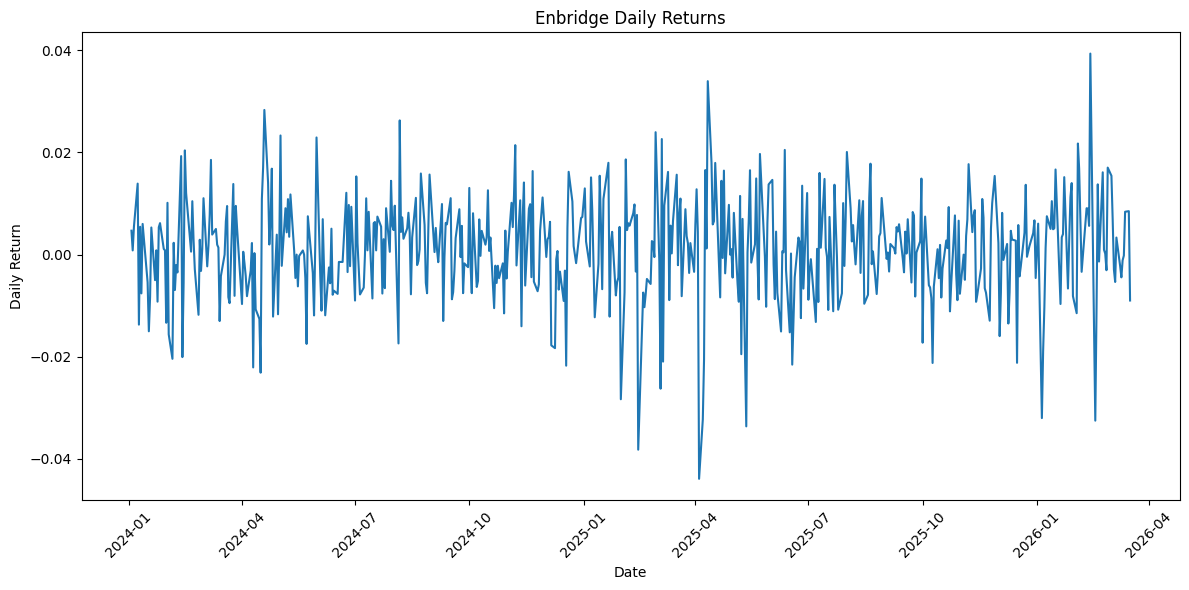

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['ENB_Return'])
plt.title('Enbridge Daily Returns')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

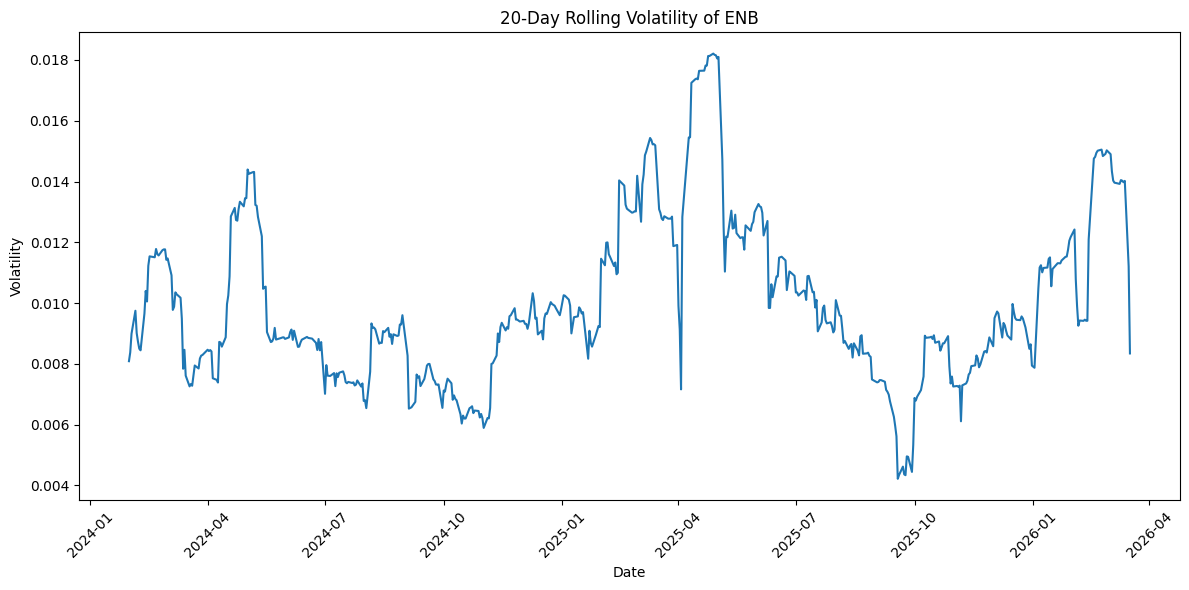

In [ ]:
# 20-day rolling volatility
df['Rolling_20D_Volatility'] = df['ENB_Return'].rolling(window=20).std()

plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Rolling_20D_Volatility'])
plt.title('20-Day Rolling Volatility of ENB')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Monte Carlo Simulation 
### Perform 100 simulations 
### Forecast stock price 30 days ahead 
### Present graphical output 
### Interpret mean forecast and risk range 

## Beta calculation using regression (slope method)

In [ ]:
# Remove the first NaN row created by pct_change()
reg_df = df[['ENB_Return', 'SP500_Return']].dropna().copy()

# Beta is the slope of ENB returns regressed on market returns
beta = np.polyfit(reg_df['SP500_Return'], reg_df['ENB_Return'], 1)[0]
alpha = np.polyfit(reg_df['SP500_Return'], reg_df['ENB_Return'], 1)[1]
correlation = reg_df['ENB_Return'].corr(reg_df['SP500_Return'])
r_squared = correlation ** 2

print(f'Beta (slope): {beta:.4f}')
print(f'Alpha (intercept): {alpha:.6f}')
print(f'Correlation: {correlation:.4f}')
print(f'R-squared: {r_squared:.4f}')

Beta (slope): 0.2216
Alpha (intercept): 0.000855
Correlation: 0.2147
R-squared: 0.0461


## Monte Carlo simulation (100 simulations, 30 trading days ahead)

In [ ]:
np.random.seed(42)

last_price = df['ENB_Close'].iloc[-1]
mu = df['ENB_Return'].dropna().mean()
sigma = df['ENB_Return'].dropna().std()

num_simulations = 100
forecast_days = 30

simulation_df = pd.DataFrame()

for i in range(num_simulations):
    prices = [last_price]
    for _ in range(forecast_days):
        simulated_return = np.random.normal(mu, sigma)
        next_price = prices[-1] * (1 + simulated_return)
        prices.append(next_price)
    simulation_df[i] = prices

print('Current price:', round(last_price, 2))
simulation_df.head()

Current price: 54.05


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,54.049999,54.049999,54.049999,54.049999,54.049999,54.049999,54.049999,54.049999,54.049999,54.049999,...,54.049999,54.049999,54.049999,54.049999,54.049999,54.049999,54.049999,54.049999,54.049999,54.049999
1,54.377746,53.773104,53.840554,54.157760,54.539757,54.242210,54.448730,54.418577,53.668068,54.897692,...,54.317247,54.781875,54.450856,54.431865,53.950807,53.802520,52.872256,53.809639,54.652899,53.051694
2,54.355827,54.841539,53.792864,54.746459,54.089451,54.488111,54.028138,55.102621,53.659295,54.150080,...,54.975353,55.777033,54.059551,54.177562,54.469406,54.313214,51.783462,54.060159,54.448174,53.067931
3,54.769004,54.889119,53.240828,54.410047,54.916566,54.165511,53.493190,55.693373,53.989193,54.845969,...,56.157253,56.152838,54.606832,54.004136,54.497025,53.756653,51.515458,53.712052,54.858056,52.381744
4,55.673576,54.353014,52.645726,54.283164,54.187719,54.348071,53.809801,56.118818,54.519487,54.906808,...,56.799180,55.706126,54.310472,53.548732,53.771893,53.931422,51.807360,54.180635,54.806758,53.494551


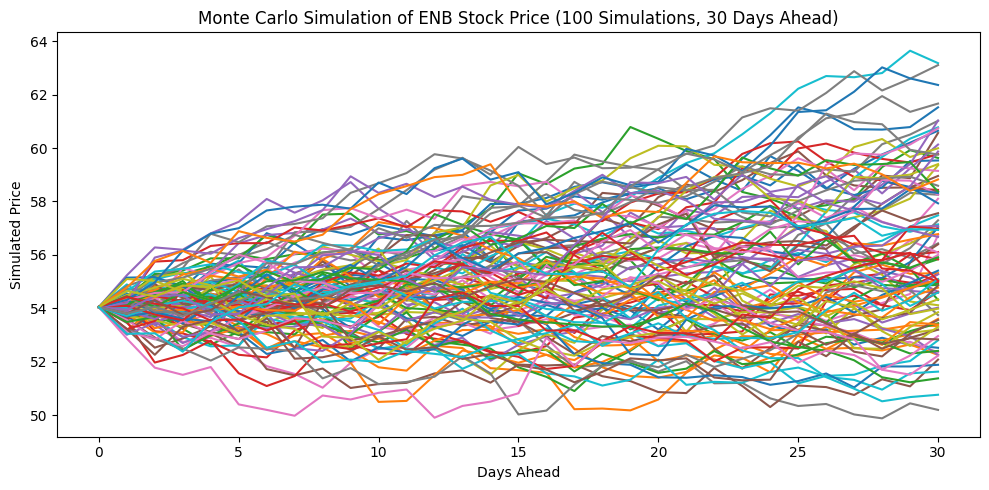

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(simulation_df)
plt.title('Monte Carlo Simulation of ENB Stock Price (100 Simulations, 30 Days Ahead)')
plt.xlabel('Days Ahead')
plt.ylabel('Simulated Price')
plt.tight_layout()
plt.show()

In [ ]:
final_prices = simulation_df.iloc[-1]

mean_forecast_price = final_prices.mean()
min_forecast_price = final_prices.min()
max_forecast_price = final_prices.max()
percentile_5 = np.percentile(final_prices, 5)
percentile_95 = np.percentile(final_prices, 95)

print(f'Mean Forecast Price after 30 Days: {mean_forecast_price:.2f}')
print(f'Minimum Forecast Price: {min_forecast_price:.2f}')
print(f'Maximum Forecast Price: {max_forecast_price:.2f}')
print(f'5th Percentile Price: {percentile_5:.2f}')
print(f'95th Percentile Price: {percentile_95:.2f}')

Mean Forecast Price after 30 Days: 56.24
Minimum Forecast Price: 50.20
Maximum Forecast Price: 63.17
5th Percentile Price: 52.08
95th Percentile Price: 61.05


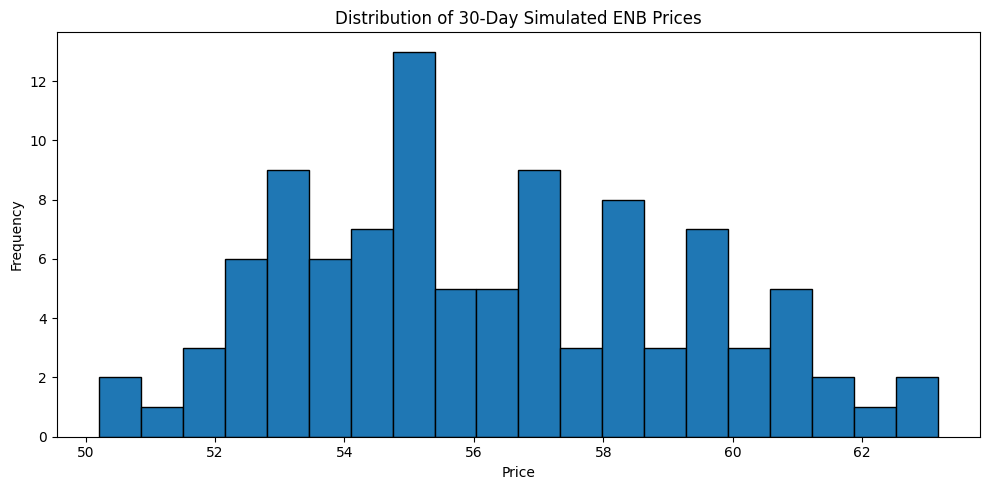

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(final_prices, bins=20, edgecolor='black')
plt.title('Distribution of 30-Day Simulated ENB Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# 3. FB Prophet Forecast 
### Forecast future price trend 
### Compare with Monte Carlo results 
### Interpret findings 

In [ ]:
prophet_df = df[['Date', 'ENB_Close']].copy()
prophet_df.columns = ['ds', 'y']
prophet_df.head()

,ds,y
0,2024-01-02,31.944403
1,2024-01-03,32.094009
2,2024-01-04,32.120407
3,2024-01-05,32.296413
4,2024-01-08,32.745213


In [ ]:
model = Prophet(daily_seasonality=True)
model.fit(prophet_df)

20:46:17 - cmdstanpy - INFO - Chain [1] start processing
20:46:17 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
578,2026-04-12,56.581383,55.727922,57.484417
579,2026-04-13,57.428176,56.500617,58.357942
580,2026-04-14,57.569285,56.648446,58.542448
581,2026-04-15,57.762933,56.817118,58.637427
582,2026-04-16,57.942039,57.017310,58.893503


<Figure size 1000x300 with 0 Axes>

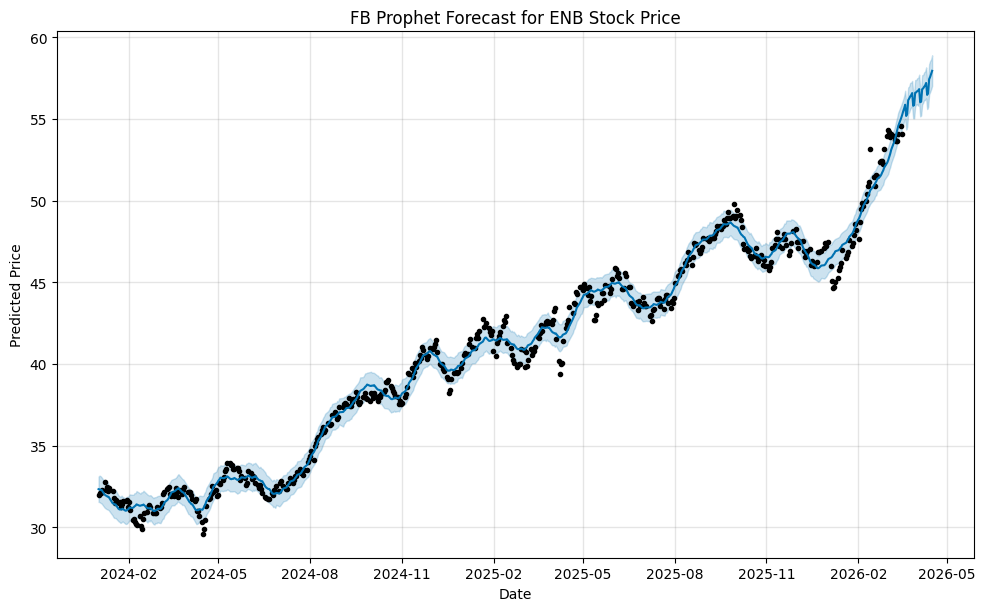

In [ ]:
plt.figure(figsize=(10, 3))
fig1 = model.plot(forecast)
plt.title('FB Prophet Forecast for ENB Stock Price')
plt.xlabel('Date')
plt.ylabel('Predicted Price')
plt.show()

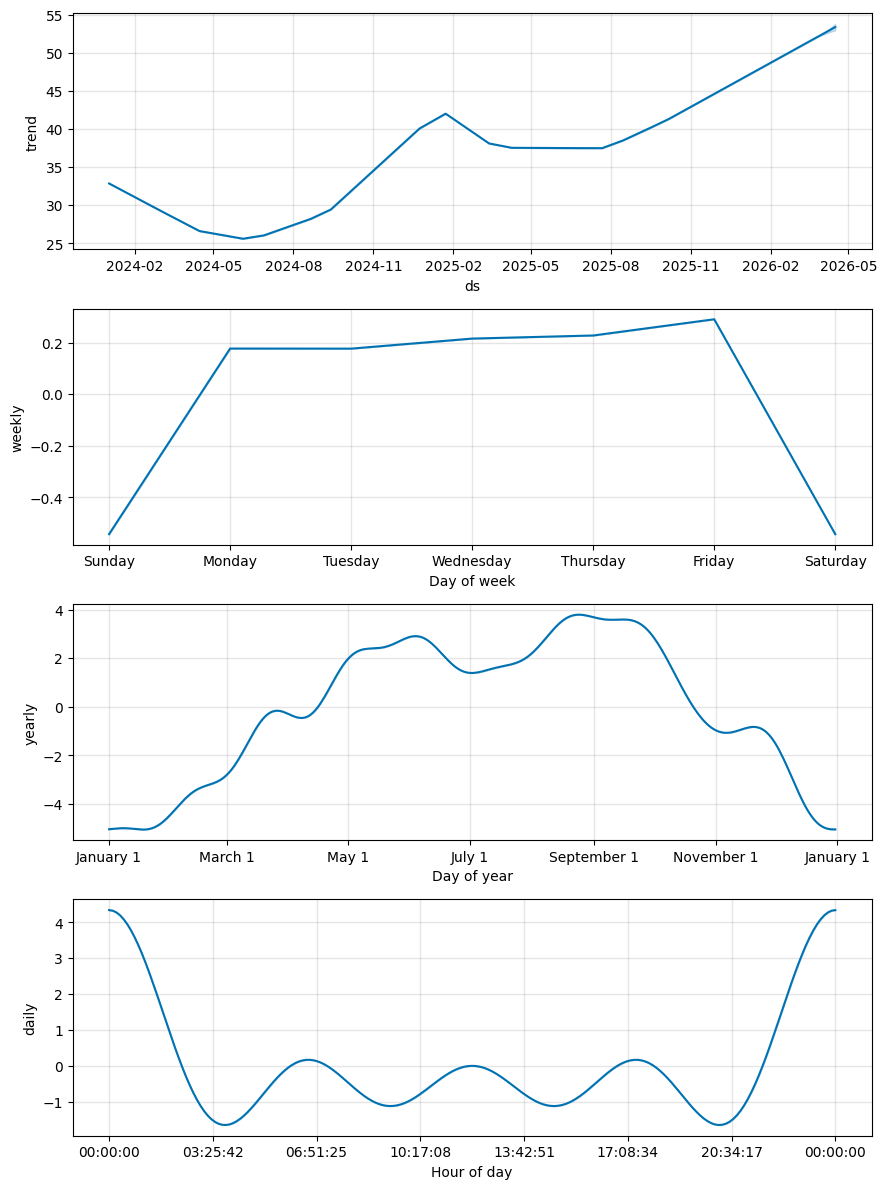

In [ ]:
fig2 = model.plot_components(forecast)
plt.show()

## Compare Monte Carlo and Prophet forecasts

In [ ]:
prophet_30d_price = forecast['yhat'].iloc[-1]

comparison_df = pd.DataFrame({
    'Method': ['Monte Carlo Mean', 'Prophet Forecast'],
    '30-Day Forecast Price': [mean_forecast_price, prophet_30d_price]
})

comparison_df

,Method,30-Day Forecast Price
0,Monte Carlo Mean,56.244450
1,Prophet Forecast,57.942039


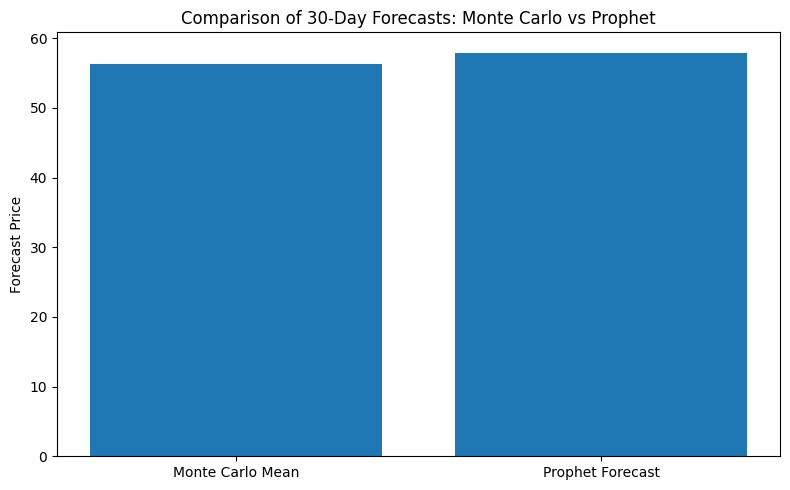

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df['Method'], comparison_df['30-Day Forecast Price'])
plt.title('Comparison of 30-Day Forecasts: Monte Carlo vs Prophet')
plt.ylabel('Forecast Price')
plt.tight_layout()
plt.show()

## Text summary for report

Use the printed values and charts from this notebook to write your interpretation. In general:

- The **one-year stock price chart** shows the recent trend in Enbridge's share price.
- **Daily return and rolling volatility** measure short-term risk and fluctuation.
- **Monte Carlo simulation** gives a range of possible prices after 30 trading days.
- **Prophet** gives a model-based future trend estimate.
- Comparing both methods helps explain expected return and uncertainty.

# Code for Trade Signals

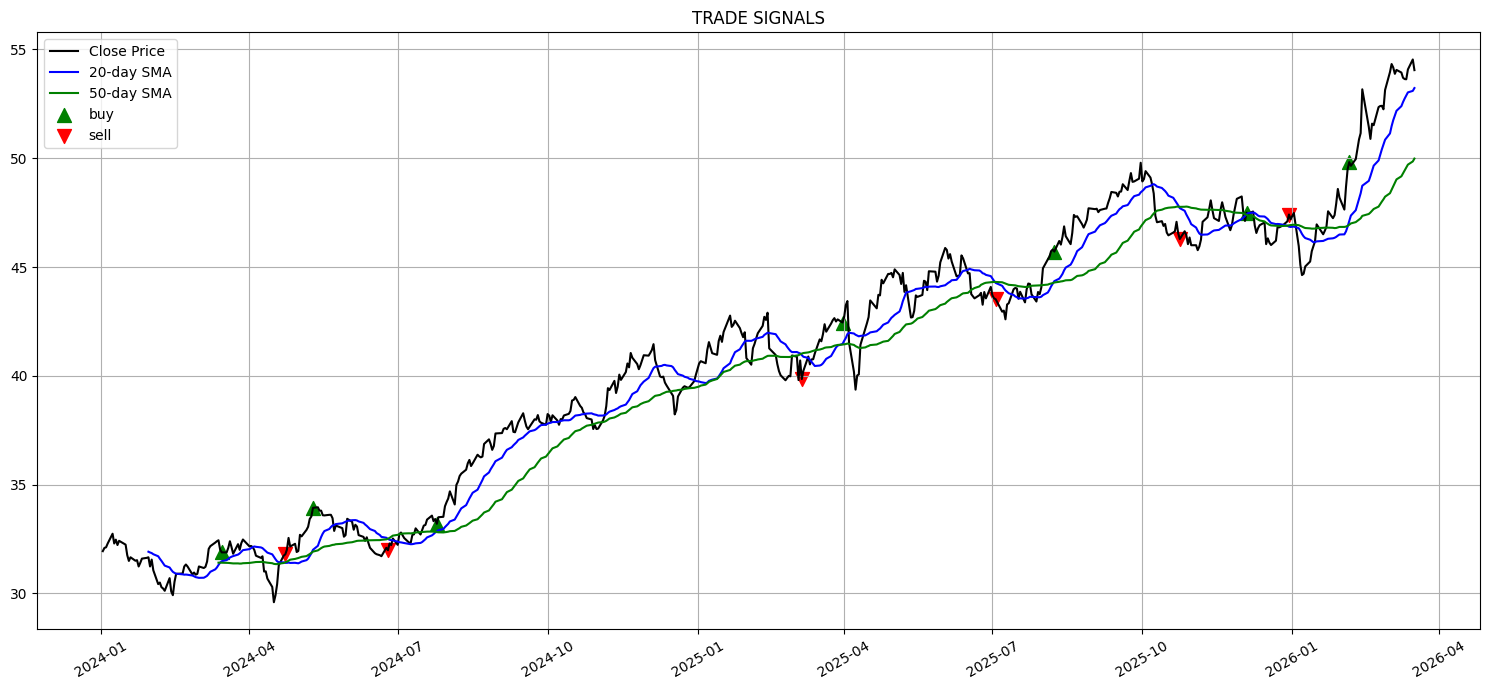

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("Stock_and_Market_Data.xlsx")

# replace these with your actual column names
date_col = "Date"
price_col = "ENB"

enb = df[[date_col, price_col]].copy()
enb.columns = ["Date", "ENB_Close"]

enb["Date"] = pd.to_datetime(enb["Date"])
enb["ENB_Close"] = pd.to_numeric(enb["ENB_Close"], errors="coerce")
enb = enb.dropna().sort_values("Date").reset_index(drop=True)

enb["SMA_20"] = enb["ENB_Close"].rolling(20).mean()
enb["SMA_50"] = enb["ENB_Close"].rolling(50).mean()

enb["Signal"] = 0
enb.loc[enb["SMA_20"] > enb["SMA_50"], "Signal"] = 1
enb.loc[enb["SMA_20"] < enb["SMA_50"], "Signal"] = -1
enb["Position"] = enb["Signal"].diff()

buy_signals = enb[enb["Position"] == 2]
sell_signals = enb[enb["Position"] == -2]

plt.figure(figsize=(15, 6))
plt.plot(enb["Date"], enb["ENB_Close"], label="Close Price", color="black")
plt.plot(enb["Date"], enb["SMA_20"], label="20-day SMA", color="blue")
plt.plot(enb["Date"], enb["SMA_50"], label="50-day SMA", color="green")
plt.scatter(buy_signals["Date"], buy_signals["ENB_Close"], marker="^", color="green", s=100, label="buy")
plt.scatter(sell_signals["Date"], sell_signals["ENB_Close"], marker="v", color="red", s=100, label="sell")
plt.title("TRADE SIGNALS")
plt.legend()
plt.grid(True)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()